In [1]:
# DATA ANALYSIS & VISUALIZATION PROJECT
# Python | Pandas + Sklearn + Matplotlib + Seaborn

In [82]:
# STEP 1: INSTALL REQUIRED LIBRARIES

# STEP 2: IMPORT LIBRARIES

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings  

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [84]:
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("✅ STEP 2 COMPLETE: All libraries imported successfully.\n")

✅ STEP 2 COMPLETE: All libraries imported successfully.



In [106]:
# STEP 3: LOAD & EXPLORE DATASET 

In [86]:
df = pd.read_csv("titanic_dataset.csv")


print("✅ STEP 3 COMPLETE: Dataset Loaded")
print(f"   Shape       : {df.shape}")
print(f"   Columns     : {list(df.columns)}")
print(f"\n── HEAD ─────────────────────────────────")
print(df.head())
print(f"\n── INFO ─────────────────────────────────")
print(df.dtypes)
print(f"\n── MISSING VALUES ───────────────────────")
print(df.isnull().sum())
print(f"\n── DESCRIPTIVE STATS ────────────────────")
print(df.describe())

✅ STEP 3 COMPLETE: Dataset Loaded
   Shape       : (891, 15)
   Columns     : ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

── HEAD ─────────────────────────────────
   survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
0         1       2  female  60.2      0      1    7.9898        S  Second   
1         1       3  female  21.5      1      1    1.1828        S   Third   
2         0       3    male  40.4      0      0    4.6967        S   Third   
3         0       3  female   NaN      0      0   44.1734        S   Third   
4         1       1    male  48.2      0      0  243.1897        S   First   

     who  adult_male deck  embark_town alive  alone  
0  woman       False  NaN  Southampton   yes  False  
1  woman       False    G  Southampton   yes  False  
2    man        True  NaN  Southampton    no   True  
3  woman       False    G  Southampton    no   T

In [87]:
# STEP 4: DATA CLEANING & PREPROCESSING

In [88]:
df.drop(columns=[col for col in ["alive", "who", "adult_male", "deck", "embark_town", "class"] if col in df.columns], inplace=True)

df["age"].fillna(df["age"].median(), inplace=True)
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

le = LabelEncoder()
df["sex_enc"]      = le.fit_transform(df["sex"])
df["embarked_enc"] = le.fit_transform(df["embarked"])

# Feature engineering
df["family_size"]  = df["sibsp"] + df["parch"]
df["is_alone"]     = (df["family_size"] == 0).astype(int)
df["fare_bin"]     = pd.qcut(df["fare"], q=4, labels=["Low","Mid","High","VHigh"])
df["age_group"]    = pd.cut(df["age"], bins=[0,12,18,35,60,100],
                            labels=["Child","Teen","Adult","Middle","Senior"])

print("\n✅ STEP 4 COMPLETE: Data cleaned & features engineered.")
print(f"   Final shape: {df.shape}")


✅ STEP 4 COMPLETE: Data cleaned & features engineered.
   Final shape: (891, 15)


In [89]:
# STEP 5: EXPLORATORY DATA ANALYSIS (EDA)

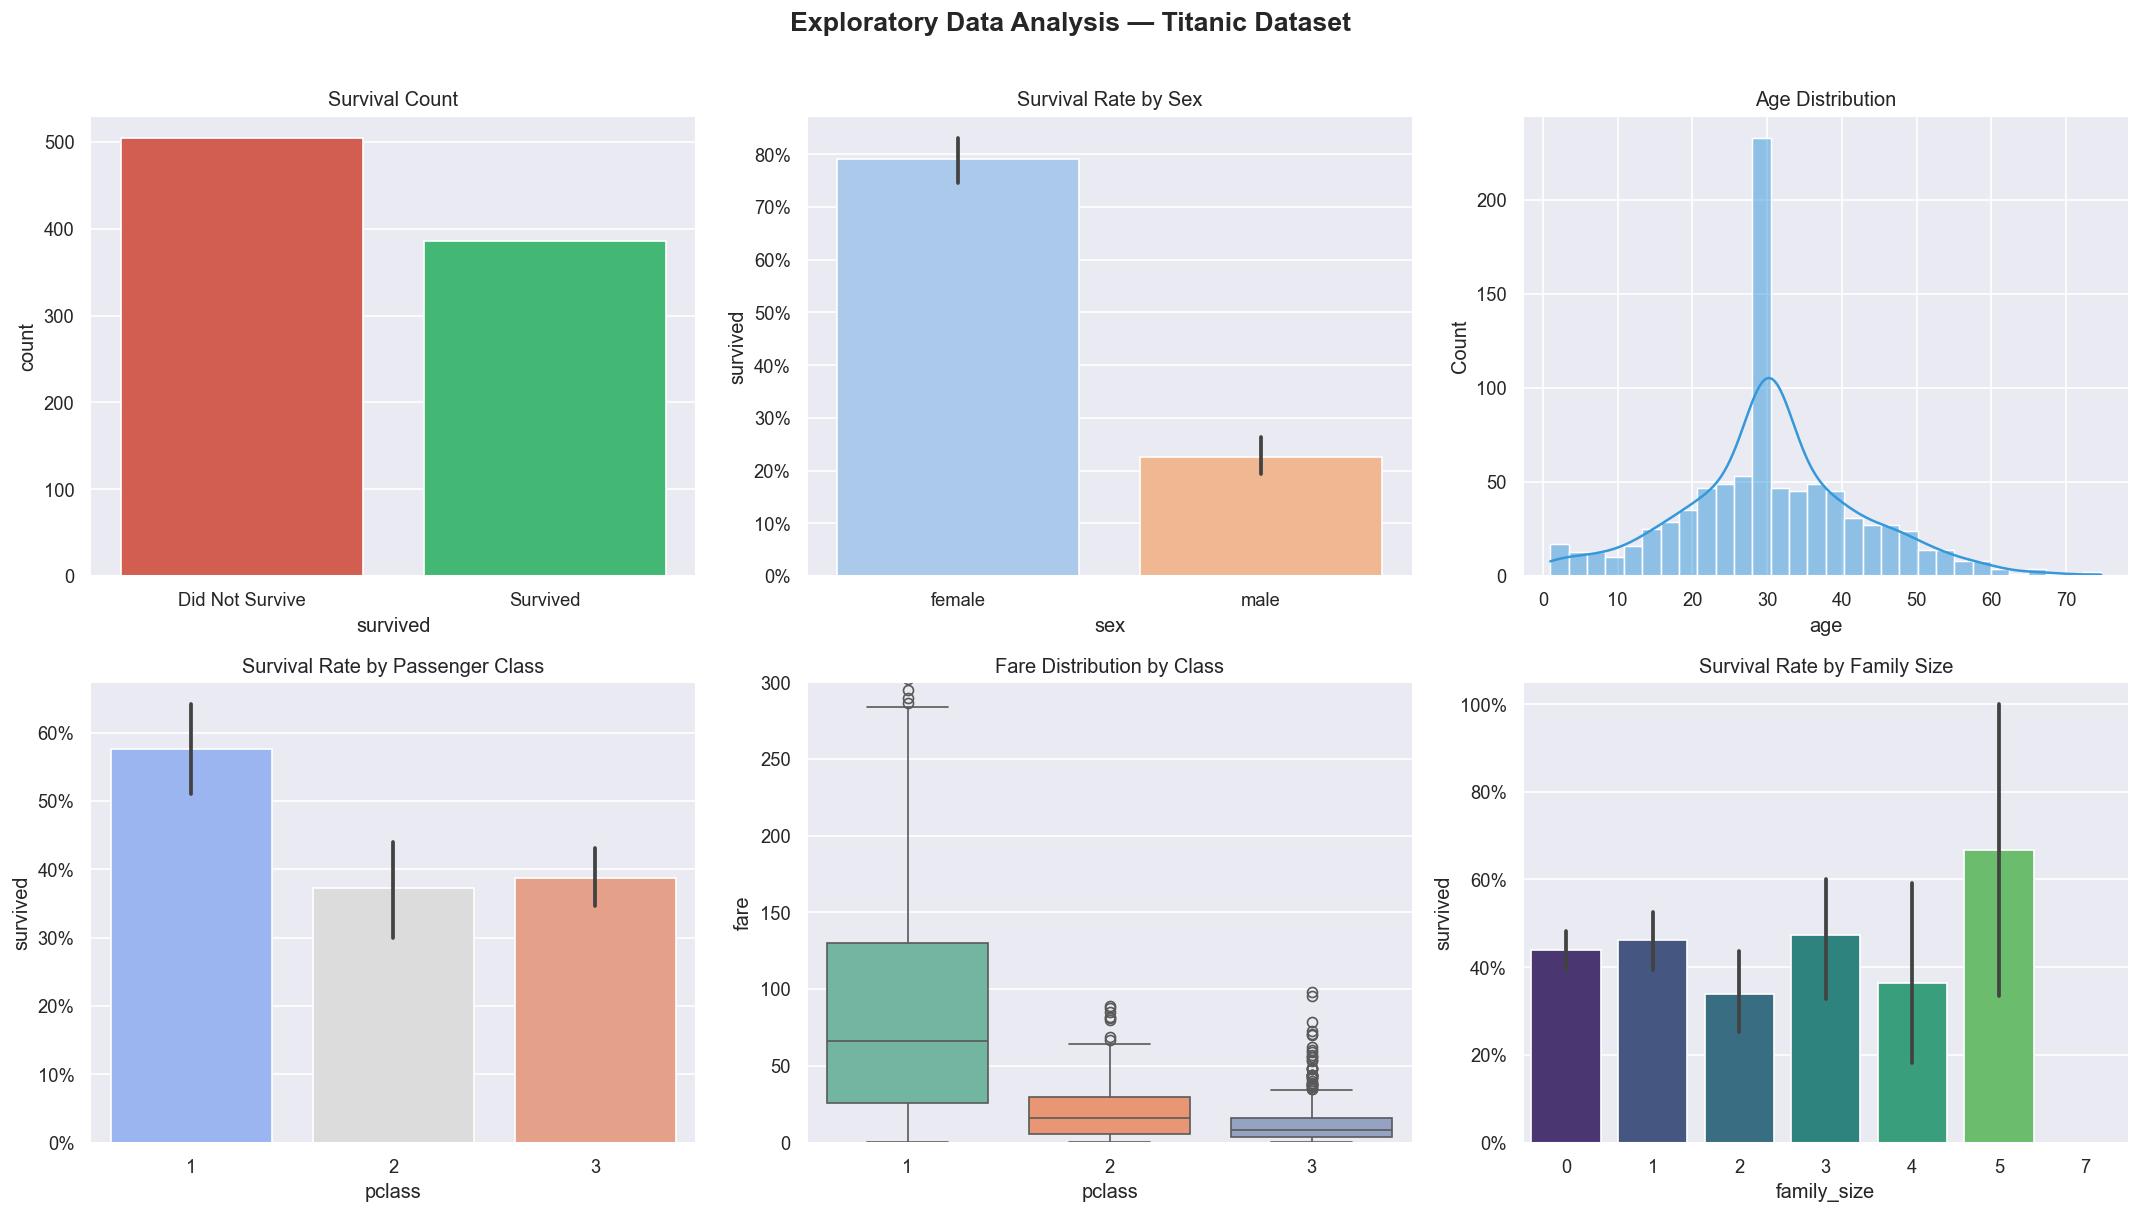


✅ STEP 5 COMPLETE: EDA visualizations saved.


In [90]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis — Titanic Dataset", fontsize=16, fontweight="bold", y=1.01)

# 5a. Survival count
sns.countplot(x="survived", data=df, palette=["#e74c3c","#2ecc71"], ax=axes[0,0])
axes[0,0].set_title("Survival Count")
axes[0,0].set_xticklabels(["Did Not Survive","Survived"])

# 5b. Survival by Sex
sns.barplot(x="sex", y="survived", data=df, palette="pastel", ax=axes[0,1])
axes[0,1].set_title("Survival Rate by Sex")
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 5c. Age distribution
sns.histplot(df["age"], bins=30, kde=True, color="#3498db", ax=axes[0,2])
axes[0,2].set_title("Age Distribution")

# 5d. Survival by Pclass
sns.barplot(x="pclass", y="survived", data=df, palette="coolwarm", ax=axes[1,0])
axes[1,0].set_title("Survival Rate by Passenger Class")
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# 5e. Fare distribution by class
sns.boxplot(x="pclass", y="fare", data=df, palette="Set2", ax=axes[1,1])
axes[1,1].set_title("Fare Distribution by Class")
axes[1,1].set_ylim(0, 300)

# 5f. Family size vs survival
sns.barplot(x="family_size", y="survived", data=df, palette="viridis", ax=axes[1,2])
axes[1,2].set_title("Survival Rate by Family Size")
axes[1,2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

import os
import matplotlib.pyplot as plt

os.makedirs("/mnt/user-data/outputs", exist_ok=True)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/eda_plots.png", bbox_inches="tight")
plt.show()

print("\n✅ STEP 5 COMPLETE: EDA visualizations saved.")

In [91]:
# STEP 6: CORRELATION HEATMAP

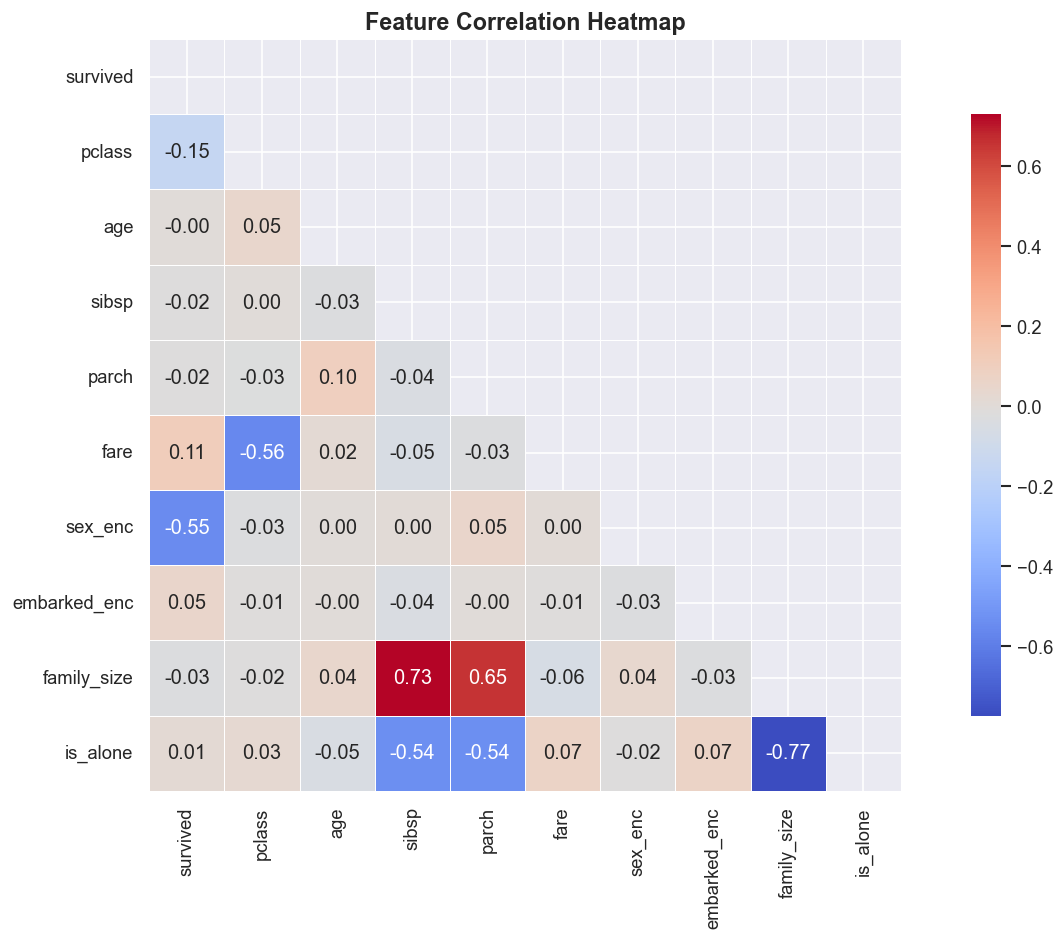

✅ STEP 6 COMPLETE: Correlation heatmap saved.


In [92]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix  = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, square=True, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ STEP 6 COMPLETE: Correlation heatmap saved.")

In [93]:
# STEP 7: PCA — DIMENSIONALITY REDUCTION

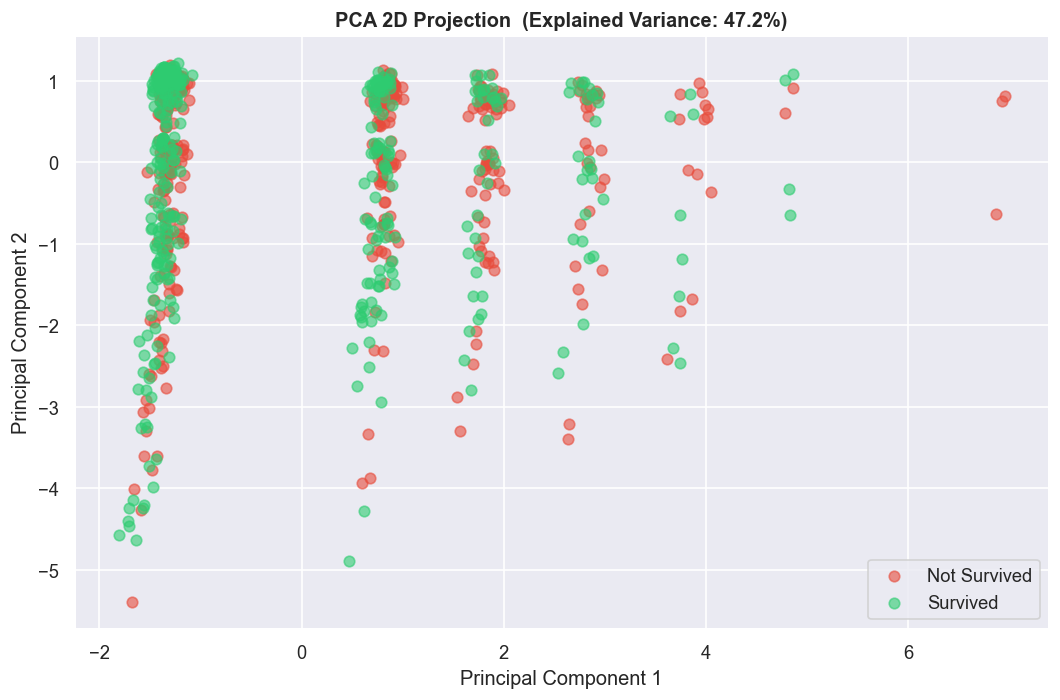


✅ STEP 7 COMPLETE: PCA — explained variance: [0.29791384 0.17366032]


In [94]:
features = ["pclass","age","sibsp","parch","fare","sex_enc","embarked_enc","family_size","is_alone"]
X_raw    = df[features].dropna()
y_raw    = df.loc[X_raw.index, "survived"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca      = PCA(n_components=2)
X_pca    = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Survived"] = y_raw.values

plt.figure(figsize=(9, 6))
colors = {0: "#e74c3c", 1: "#2ecc71"}
for label, group in pca_df.groupby("Survived"):
    plt.scatter(group["PC1"], group["PC2"], label=f"{'Survived' if label else 'Not Survived'}",
                alpha=0.6, s=40, color=colors[label])
plt.title(f"PCA 2D Projection  (Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%)",
          fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/pca_plot.png", bbox_inches="tight")
plt.show()
print(f"\n✅ STEP 7 COMPLETE: PCA — explained variance: {pca.explained_variance_ratio_}")

In [95]:
# STEP 8: K-MEANS CLUSTERING

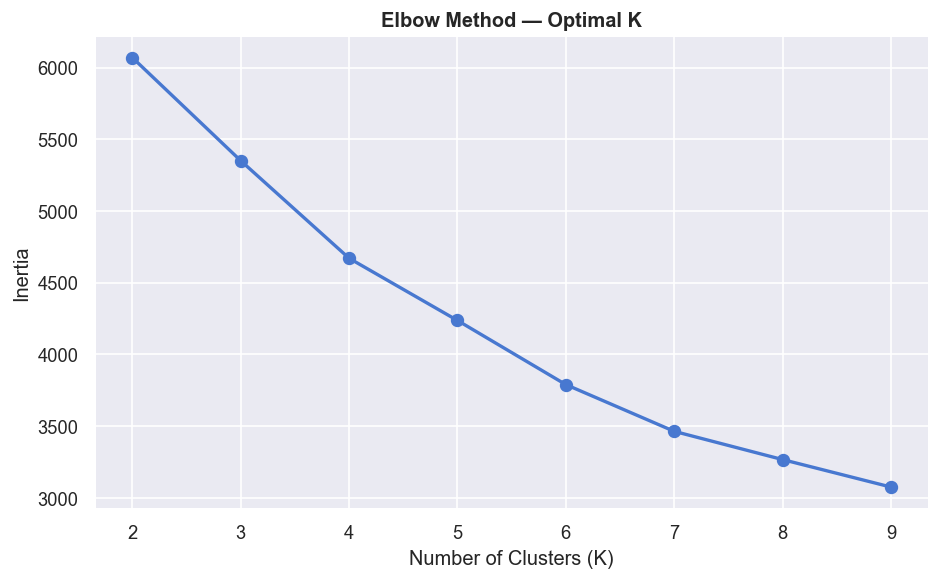

In [96]:
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, "bo-", linewidth=2, markersize=7)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method — Optimal K", fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/elbow_curve.png", bbox_inches="tight")
plt.show()



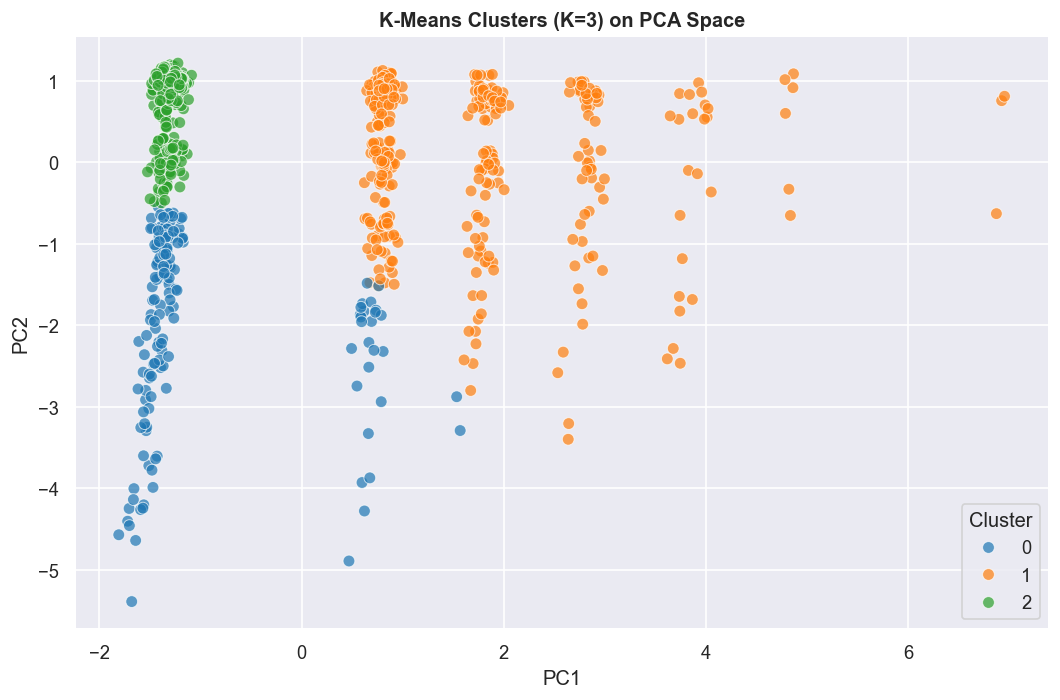

✅ STEP 8 COMPLETE: K-Means clustering done.


In [97]:
# Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster",
                palette="tab10", alpha=0.7, s=50)
plt.title("K-Means Clusters (K=3) on PCA Space", fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/kmeans_clusters.png", bbox_inches="tight")
plt.show()
print("✅ STEP 8 COMPLETE: K-Means clustering done.")

In [98]:
# STEP 9: RANDOM FOREST CLASSIFICATION


✅ STEP 9 COMPLETE: Random Forest trained.

── CLASSIFICATION REPORT ────────────────
              precision    recall  f1-score   support

Not Survived       0.85      0.78      0.81       101
    Survived       0.74      0.82      0.78        78

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.80      0.80       179



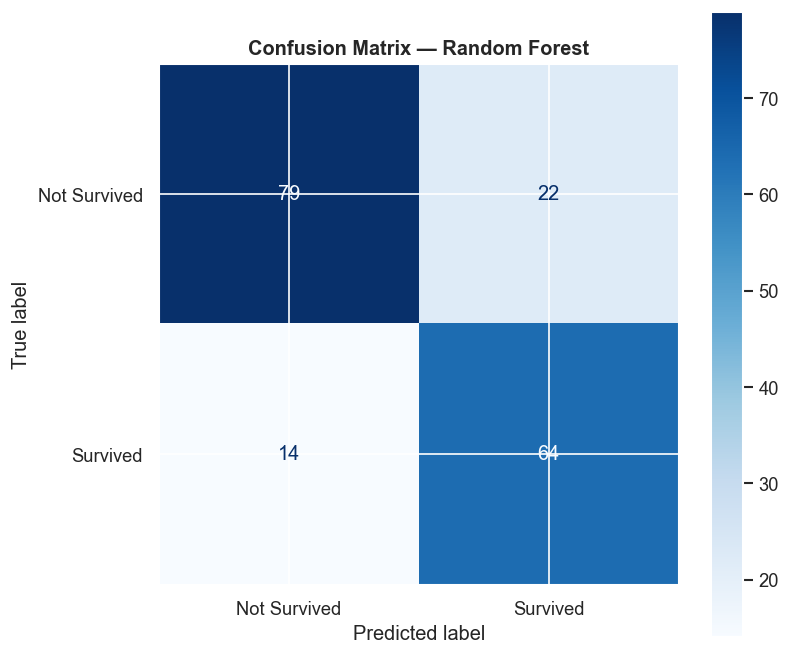

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\n✅ STEP 9 COMPLETE: Random Forest trained.")
print("\n── CLASSIFICATION REPORT ────────────────")
print(classification_report(y_test, y_pred, target_names=["Not Survived","Survived"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived","Survived"])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(cmap="Blues", ax=ax)
ax.set_title("Confusion Matrix — Random Forest", fontweight="bold")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/confusion_matrix.png", bbox_inches="tight")
plt.show()

In [100]:
# STEP 10: FEATURE IMPORTANCE

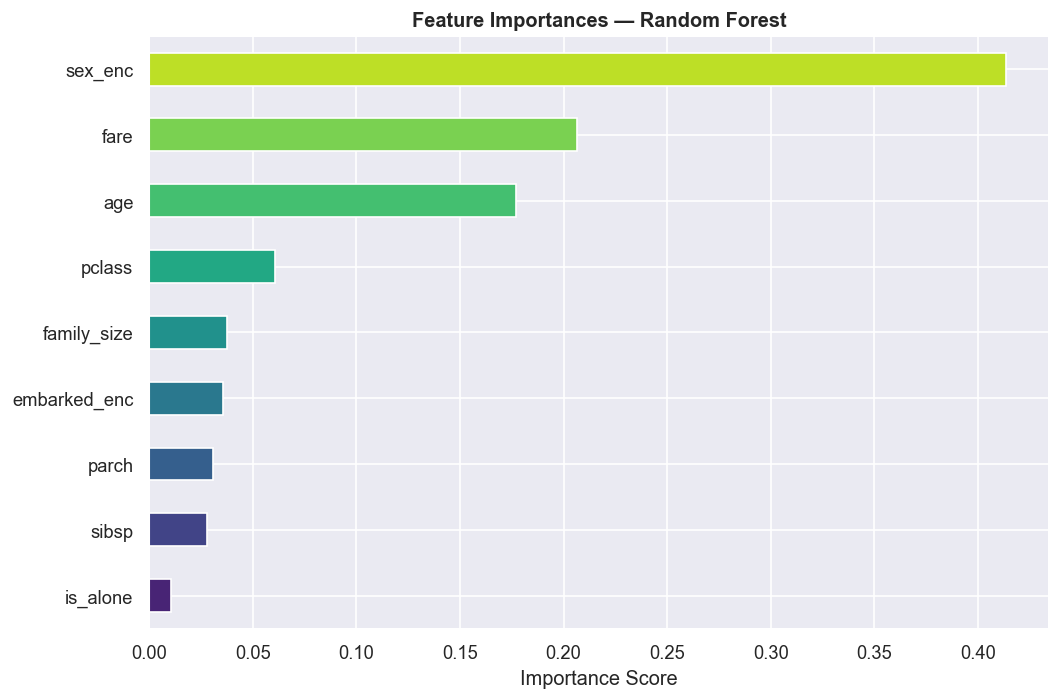


── FEATURE IMPORTANCES ──────────────────
sex_enc         0.413527
fare            0.206412
age             0.177175
pclass          0.060642
family_size     0.037654
embarked_enc    0.035543
parch           0.030656
sibsp           0.027720
is_alone        0.010671
dtype: float64


In [101]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color=sns.color_palette("viridis", len(importances)))
plt.title("Feature Importances — Random Forest", fontweight="bold")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/feature_importance.png", bbox_inches="tight")
plt.show()

print("\n── FEATURE IMPORTANCES ──────────────────")
print(importances.sort_values(ascending=False))

In [102]:
# STEP 11: INTERACTIVE PLOTLY CHART

In [114]:
fig_px = px.scatter(
    pca_df, x="PC1", y="PC2",
    color=pca_df["Survived"].map({0:"Not Survived", 1:"Survived"}),
    symbol="Cluster",
    title="Interactive PCA — Survival & Cluster View",
    color_discrete_map={"Not Survived":"#e74c3c","Survived":"#2ecc71"},
    template="plotly_dark",
    opacity=0.75,
    labels={"color":"Outcome","symbol":"Cluster"}
)
fig_px.update_traces(marker=dict(size=7))
fig_px.write_html("/mnt/user-data/outputs/interactive_pca.html")
print("\n✅ STEP 11 COMPLETE: Interactive chart saved as HTML.")


✅ STEP 11 COMPLETE: Interactive chart saved as HTML.


In [110]:
# ✅ PROJECT COMPLETE SUMMARY

In [111]:
print("""
╔══════════════════════════════════════════════════════╗
║        DATA ANALYSIS PROJECT — COMPLETE ✅           ║ 
╠══════════════════════════════════════════════════════╣
║  STEP 1  │ Library Installation                      ║
║  STEP 2  │ Import Libraries                          ║
║  STEP 3  │ Load & Explore Dataset                    ║
║  STEP 4  │ Data Cleaning & Feature Engineering       ║
║  STEP 5  │ EDA Visualizations (6 plots)              ║
║  STEP 6  │ Correlation Heatmap                       ║
║  STEP 7  │ PCA Dimensionality Reduction              ║
║  STEP 8  │ K-Means Clustering (Elbow + Clusters)     ║
║  STEP 9  │ Random Forest Classification              ║
║  STEP 10 │ Feature Importance Analysis               ║
║  STEP 11 │ Interactive Plotly Chart (HTML)           ║
╚══════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════╗
║        DATA ANALYSIS PROJECT — COMPLETE ✅           ║
╠══════════════════════════════════════════════════════╣
║  STEP 1  │ Library Installation                      ║
║  STEP 2  │ Import Libraries                          ║
║  STEP 3  │ Load & Explore Dataset                    ║
║  STEP 4  │ Data Cleaning & Feature Engineering       ║
║  STEP 5  │ EDA Visualizations (6 plots)              ║
║  STEP 6  │ Correlation Heatmap                       ║
║  STEP 7  │ PCA Dimensionality Reduction              ║
║  STEP 8  │ K-Means Clustering (Elbow + Clusters)     ║
║  STEP 9  │ Random Forest Classification              ║
║  STEP 10 │ Feature Importance Analysis               ║
║  STEP 11 │ Interactive Plotly Chart (HTML)           ║
╚══════════════════════════════════════════════════════╝

